In [14]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit_aer.primitives import Sampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.translators.docplex_mp import to_docplex_mp
import numpy as np
import matplotlib.pyplot as plt
import datetime

## Introduction

This tutorial shows how to solve the following mean-variance portfolio optimization problem for $n$ assets:

$$\begin{aligned}
\min_{x \in \{0, 1\}^n}  q x^T \Sigma x - \mu^T x\\
\text{subject to: } 1^T x = B
\end{aligned}$$

where we use the following notation:

- $x \in \{0, 1\}^n$ denotes the vector of binary decision variables, which indicate which assets to pick ($x[i] = 1$) and which not to pick ($x[i] = 0$),
- $\mu \in \mathbb{R}^n$ defines the expected returns for the assets,
- $\Sigma \in \mathbb{R}^{n \times n}$ specifies the covariances between the assets,
- $q > 0$ controls the risk appetite of the decision maker,
- and $B$ denotes the budget, i.e. the number of assets to be selected out of $n$.

We assume the following simplifications:
- all assets have the same price (normalized to 1),
- the full budget $B$ has to be spent, i.e. one has to select exactly $B$ assets.

## Define problem instance

Here an Operator instance is created for our Hamiltonian. In this case the paulis are from an Ising Hamiltonian translated from the portfolio problem. We use a random portfolio problem for this notebook. It is straight-forward to extend this to using real financial data as illustrated here:<br>
[Loading and Processing Stock-Market Time-Series Data](11_time_series.ipynb)

In [15]:
# set number of assets (= number of qubits)
num_assets = 4
seed = 123

# Generate expected return and covariance matrix from (random) time-series
stocks = [("TICKER%s" % i) for i in range(num_assets)]
data = RandomDataProvider(
    tickers=stocks,
    start=datetime.datetime(2016, 1, 1),
    end=datetime.datetime(2016, 1, 30),
    seed=seed,
)
data.run()
mu = data.get_period_return_mean_vector()
sigma = data.get_period_return_covariance_matrix()

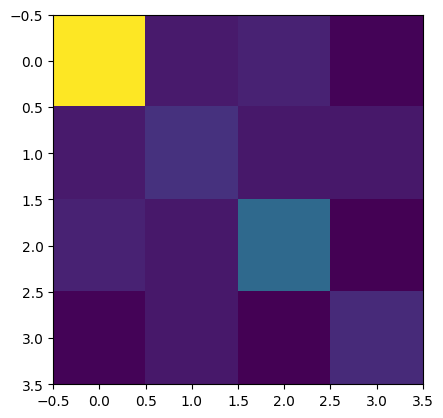

In [16]:
# plot sigma
plt.imshow(sigma, interpolation="nearest")
plt.show()

In [17]:
q = 0.5  # set risk factor
budget = num_assets // 2  # set budget
penalty = num_assets  # set parameter to scale the budget penalty term

portfolio = PortfolioOptimization(
    expected_returns=mu, covariances=sigma, risk_factor=q, budget=budget
)
qp = portfolio.to_quadratic_program()
qp

<QuadraticProgram: minimize 0.001270694296030004*x_0^2 + 7.34022166934733e-05*..., 4 variables, 1 constraints, 'Portfolio optimization'>

In [19]:
# 3. Convert it back to a DOcplex model
cplex_model = to_docplex_mp(qp)

# Now you can use standard DOcplex commands
print(cplex_model.export_as_lp_string())
#cplex_model.solve()

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Portfolio optimization

Minimize
 obj: - 0.015284386652 x_0 + 0.000780952145 x_1 - 0.000517920547 x_2
      - 0.000870005837 x_3 + [ 0.002541388592 x_0^2 + 0.000146804433 x_0*x_1
      + 0.000257201062 x_0*x_2 - 0.000199722426 x_0*x_3 + 0.000258486713 x_1^2
      + 0.000106085519 x_1*x_2 + 0.000088963242 x_1*x_3 + 0.000791504681 x_2^2
      - 0.000247774763 x_2*x_3 + 0.000197892585 x_3^2 ]/2
Subject To
 c0: x_0 + x_1 + x_2 + x_3 = 2

Bounds
 0 <= x_0 <= 1
 0 <= x_1 <= 1
 0 <= x_2 <= 1
 0 <= x_3 <= 1

Binaries
 x_0 x_1 x_2 x_3
End



In [20]:
def print_result(result):
    selection = result.x
    value = result.fval
    print("Optimal: selection {}, value {:.4f}".format(selection, value))

    eigenstate = result.min_eigen_solver_result.eigenstate
    probabilities = (
        eigenstate.binary_probabilities()
        if isinstance(eigenstate, QuasiDistribution)
        else {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}
    )
    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")
    probabilities = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for k, v in probabilities:
        x = np.array([int(i) for i in list(reversed(k))])
        value = portfolio.to_quadratic_program().objective.evaluate(x)
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

## NumPyMinimumEigensolver (as a classical reference)
Lets solve the problem. First classically...

We can now use the Operator we built above without regard to the specifics of how it was created. We set the algorithm for the NumPyMinimumEigensolver so we can have a classical reference. The problem is set for 'ising'. Backend is not required since this is computed classically not using quantum computation. The result is returned as a dictionary.

In [21]:
exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

result = exact_eigensolver.solve(qp)

print_result(result)

Optimal: selection [1. 0. 0. 1.], value -0.0149

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [1 0 0 1]	-0.0149		1.0000


In [14]:
import numpy as np
from docplex.mp.model import Model

# --- 1. Set Parameters (Quick Test Scenario) ---
n_assets = 30       # K: Number of available assets
n_periods = 12      # T: Number of time periods (e.g., 1 year of monthly data)
r_star = 0.08       # Target expected return
r_min = -1.0        # Minimum allowable return
r_var = 0.05        # Return threshold for binary logic
prob = 1.0 / n_periods
k_limit = 5         # Cardinality: Max number of assets to select

# --- 2. Generate Synthetic Data ---
# Random returns for 30 assets over 12 periods
np.random.seed(0)
expected_returns = 0.25 * np.random.randn(n_periods, n_assets)

# --- 3. Build the Model ---
mdl = Model(name='Quick_Portfolio_Optimization')

# Variables
w = mdl.continuous_var_list(n_assets, lb=0, ub=1.0, name='w')    # Asset weights
x = mdl.continuous_var_list(n_periods, lb=-10, name='x')        # Period returns
y = mdl.binary_var_list(n_periods, name='y')                    # Period binary flags
z = mdl.binary_var_list(n_assets, name='z')                     # Asset selection flags
avar = mdl.continuous_var(lb=-mdl.infinity, name='avar')        # Objective variable

# --- 4. Define Constraints ---

# C1: Calculate realized return for each period
# x[i] = sum(return_ij * w_j)
for i in range(n_periods):
    mdl.add_constraint(x[i] == mdl.sum(expected_returns[i, j] * w[j] for j in range(n_assets)))

# C2: Target Return Constraint
# Average return over all periods must be >= r_star
mdl.add_constraint(mdl.sum(prob * x[i] for i in range(n_periods)) >= r_star)

# C3: Period Logic (based on NAG structure)
# If y[i]=1, x[i] must be >= r_var. If y[i]=0, x[i] must be >= r_min.
y_coef = r_min - r_var
for i in range(n_periods):
    mdl.add_constraint(x[i] + y_coef * y[i] >= r_min)

# C4: Average Value at Risk Link
# sum(prob * y[i]) + avar >= 1.0
mdl.add_constraint(mdl.sum(prob * y[i] for i in range(n_periods)) + avar >= 1.0)

# C5: Budget Constraint
# Total weight must equal 100%
mdl.add_constraint(mdl.sum(w) == 1.0)

# C6: Semi-continuous bounds (Logic for z[j])
# Asset weight must be between 5% and 70% if selected, otherwise 0.
for j in range(n_assets):
    mdl.add_constraint(w[j] <= 0.7 * z[j])   # Max weight
    mdl.add_constraint(w[j] >= 0.05 * z[j])  # Min weight (buy-in threshold)

# C7: Cardinality Constraint
# Pick no more than k_limit assets
mdl.add_constraint(mdl.sum(z) <= k_limit)

# --- 5. Solve ---
mdl.minimize(avar)


In [15]:
mdl.prettyprint()

// This file has been generated by DOcplex
// model name is: Quick_Portfolio_Optimization
// var contrainer section
dvar float w[30];
dvar float x[12];
dvar bool y[12];
dvar bool z[30];

// single vars section
dvar float avar;

minimize
 avar;
 
subject to {
 x_0 == 0.441013 w_0 + 0.100039 w_1 + 0.244684 w_2 + 0.560223 w_3
 + 0.466889 w_4 - 0.244319 w_5 + 0.237522 w_6 - 0.037839 w_7 - 0.025805 w_8
 + 0.102650 w_9 + 0.036011 w_10 + 0.363568 w_11 + 0.190259 w_12
 + 0.030419 w_13 + 0.110966 w_14 + 0.083419 w_15 + 0.373520 w_16
 - 0.051290 w_17 + 0.078267 w_18 - 0.213524 w_19 - 0.638247 w_20
 + 0.163405 w_21 + 0.216109 w_22 - 0.185541 w_23 + 0.567439 w_24
 - 0.363591 w_25 + 0.011440 w_26 - 0.046796 w_27 + 0.383195 w_28
 + 0.367340 w_29;
 x_1 == 0.038737 w_0 + 0.094541 w_1 - 0.221946 w_2 - 0.495199 w_3
 - 0.086978 w_4 + 0.039087 w_5 + 0.307573 w_6 + 0.300595 w_7 - 0.096832 w_8
 - 0.075576 w_9 - 0.262138 w_10 - 0.355004 w_11 - 0.426568 w_12
 + 0.487694 w_13 - 0.127413 w_14 - 0.109519 w_15 - 

In [16]:
import numpy as np
from qsw-2026-dqi-kit.dqi_kit import MaxConstraintSat

# --- 1. Parameters & Discretization ---
n_assets = 6
n_periods = 5
SCALE = 100  # Scaling factor to turn floats into integers (e.g., 0.08 -> 8)

r_star_int = int(0.08 * SCALE)
r_min_int = int(-1.0 * SCALE)
r_var_int = int(0.05 * SCALE)
k_limit = 5

# Scale the synthetic returns matrix
np.random.seed(0)
returns = (0.25 * np.random.randn(n_periods, n_assets) * SCALE).astype(int)

# --- 2. Initialize DQI-Kit Framework ---
# Using MaxConstraintSat for high-level integer/Boolean modeling (Section VI-B)
prob = MaxConstraintSat()

# --- 3. Define Variables with Bounds ---
# DQI-Kit requires explicit lower/upper bounds for all variables
# Weights (w): 0% to 100%
w = [prob.new_var(f"w_{j}", lower=0, upper=100) for j in range(n_assets)]

# Realized returns (x): Estimated range based on data
x = [prob.new_var(f"x_{i}", lower=-500, upper=500) for i in range(n_periods)]

# Binary flags (y and z): lower=0, upper=1 automatically makes them binary logic compatible
y = [prob.new_binary_var(f"y_{i}") for i in range(n_periods)]
z = [prob.new_binary_var(f"z_{j}") for j in range(n_assets)]

# Objective variable (avar)
avar = prob.new_var("avar", lower=-1000, upper=1000)

# --- 4. Define Constraints ---

# C1: Realized return for each period (Linear Equality)
for i in range(n_periods):
    # DQI-Kit handles linear combinations of IntVars (Section III-A)
    actual_return = sum(returns[i, j] * w[j] for j in range(n_assets))
    prob.add_constraint(x[i] * SCALE == actual_return, weight=10)

# C2: Target Return Constraint (Inequality)
# sum(x[i]/n_periods) >= r_star  => sum(x[i]) >= r_star * n_periods
prob.add_constraint(sum(x) >= r_star_int * n_periods, weight=5)

# C3: Period Logic (Big-M formulation)
# x[i] + (r_min - r_var) * y[i] >= r_min
y_coef = r_min_int - r_var_int
for i in range(n_periods):
    prob.add_constraint(x[i] + y_coef * y[i] >= r_min_int, weight=5)

# C4: Average Value at Risk Link
# sum(y[i]/n_periods) + avar >= 1.0 => sum(y[i]) + n_periods * avar >= n_periods
prob.add_constraint(sum(y) + n_periods * avar >= n_periods, weight=5)

# C5: Budget Constraint (Total weight = 100%)
prob.add_constraint(sum(w) == 100, weight=20)

# C6: Semi-continuous bounds (Logic for z[j])
for j in range(n_assets):
    # w[j] <= 70% * z[j]
    prob.add_constraint(w[j] <= 70 * z[j], weight=10)
    # w[j] >= 5% * z[j]
    prob.add_constraint(w[j] >= 5 * z[j], weight=10)

# C7: Cardinality Constraint (Maximum assets)
prob.add_constraint(sum(z) <= k_limit, weight=5)

# --- 5. Set Objective ---
# MaxConstraintSat defaults to maximization. Negate for minimization.
prob.add_objective(-avar)

# --- 6. Solve/Estimate ---
# To solve, DQI-Kit transforms this into Max-LINSAT (Section VI-B)
max_lin_sat_inst = prob.to_max_lin_sat()

# You can now use a classical solver or estimate DQI performance
from dqi_kit import Dqi
dqi_engine = Dqi(max_lin_sat_inst)
print(f"DQI Quality Estimate (degree 2): {dqi_engine.estimate_solution_quality(2)}")

SyntaxError: invalid syntax (3415868895.py, line 2)

In [17]:
import numpy as np
from dqi_kit import MaxConstraintSat, Dqi

# --- 1. Prepare Data from your previous snippet ---
# (Assume mu, sigma, budget, and num_assets are already defined)
# Since DQI-Kit uses integer weights (Section V), scale the floats
SCALE = 10000 
scaled_mu = (mu * SCALE).astype(int)
scaled_sigma = (sigma * SCALE).astype(int)
q_factor = 0.5

# --- 2. Initialize DQI-Kit Abstraction ---
# We use MaxConstraintSat because it handles Boolean/Binary logic (Section VI-B)
prob = MaxConstraintSat()

# Create binary variables for the assets
x = [prob.new_binary_var(f"x_{i}") for i in range(num_assets)]

# --- 3. Define the Quadratic Objective ---
# In DQI-Kit, we define the objective to be MAXIMIZED. 
# QUBO Minimize: q * x.T @ sigma @ x - mu.T @ x
# DQI-Kit Maximize: mu.T @ x - q * x.T @ sigma @ x

# Add Linear Terms (mu)
linear_objective = sum(scaled_mu[i] * x[i] for i in range(num_assets))

# Add Quadratic Terms (sigma)
# DQI-Kit supports polynomial objectives (Section III-C)
quadratic_objective = 0
for i in range(num_assets):
    for j in range(num_assets):
        # x_i * x_j is automatically handled via auxiliary variables 
        # as described in the "Polynomial Constraints" section of the paper.
        quadratic_objective += scaled_sigma[i, j] * x[i] * x[j]

prob.add_objective(linear_objective - q_factor * quadratic_objective)

# --- 4. Add the Budget Constraint ---
# The paper treats constraints as soft weighted constraints (Section III)
# We set a high weight to ensure the budget is respected.
prob.add_constraint(sum(x) == budget, weight=SCALE * 10)

# --- 5. Transform and Estimate ---
# This step performs the transformations shown in Figure 1 of the paper
max_lin_sat_inst = prob.to_max_lin_sat()

# Create the DQI solver/estimator
dqi = Dqi(max_lin_sat_inst)

# Estimate performance for a trial state of degree l=2
# This allows checking performance without a real quantum device (Section VI-C)
quality = dqi.estimate_solution_quality(l=2)
print(f"DQI Estimated Satisfied Constraints: {quality}")

ModuleNotFoundError: No module named 'dqi_kit'